<a href="https://colab.research.google.com/github/ogeorgehenrique/YoloV11-para-Segmenta-o-de-Bovinos/blob/main/YoloV11_para_Segmenta%C3%A7%C3%A3o_de_Bovinos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Segmentação de Imagens com Arquitetura YOLOv11**

**Objetivo:** Este notebook tem como objetivo treinar um modelo de **segmentação de imagens** utilizando uma arquitetura mais recente, informalmente conhecida como **"YOLOv11"**. É importante notar que este modelo opera sobre o robusto e estabelecido framework da **Ultralytics**, o mesmo utilizado pelo YOLOv8.

**Passos do Projeto:**
1.  **Configuração do Ambiente:** Preparação do ambiente e instalação da biblioteca `ultralytics`.
2.  **Download do Dataset:** Obtenção das imagens e anotações da plataforma Roboflow.
3.  **Treinamento do Modelo:** Treinamento de um modelo de segmentação com os pesos pré-treinados `yolo11n-seg.pt`.
4.  **Análise do Treinamento:** Visualização de gráficos e métricas, como a matriz de confusão e os resultados por época.
5.  **Validação:** Avaliação objetiva da performance do modelo treinado.
6.  **Predição (Inferência):** Uso do modelo para segmentar novas imagens.
7.  **Visualização Final:** Exibição dos resultados da predição diretamente no notebook.

In [ ]:
!pip -q install -U ultralytics
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output() # Limpa a saída da célula
!yolo checks

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 39.7/112.6 GB disk)

OS                     Linux-6.6.105+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.12.12
Install                pip
Path                   /usr/local/lib/python3.12/dist-packages/ultralytics
RAM                    52.96 GB
Disk                   39.7/112.6 GB
CPU                    Intel Xeon CPU @ 2.20GHz
CPU count              12
GPU                    NVIDIA L4, 22693MiB
GPU count              1
CUDA                   12.6

numpy                  ✅ 2.0.2>=1.23.0
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 4.12.0.88>=4.6.0
pillow                 ✅ 11.3.0>=7.1.2
pyyaml                 ✅ 6.0.3>=5.3.1
requests               ✅ 2.32.4>=2.23.0
scipy                  ✅ 1.16.2>=1.4.1
torch                  ✅ 2.8.0+cu126>=1.8.0
torch                  ✅ 2.8.0+cu126!=2.4.0,>=1.8.0; sys_platform == "win

In [ ]:
Substitua o codigo desta celula pelo codigo do seu roboflow!!!!

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="COLOQUE SEU CODIGO DO ROBOFLOW")
project = rf.workspace("COLOQUE SEU CODIGO DO ROBOFLOW").project("COLOQUE SEU CODIGO DO ROBOFLOW")
version = project.version(4)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!yolo task=segment mode=train model=yolo11n-seg.pt data="/content/SegmentacaoBoi-4/data.yaml" batch=6 epochs=20 imgsz=640 plots=True

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/SegmentacaoBoi-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=T

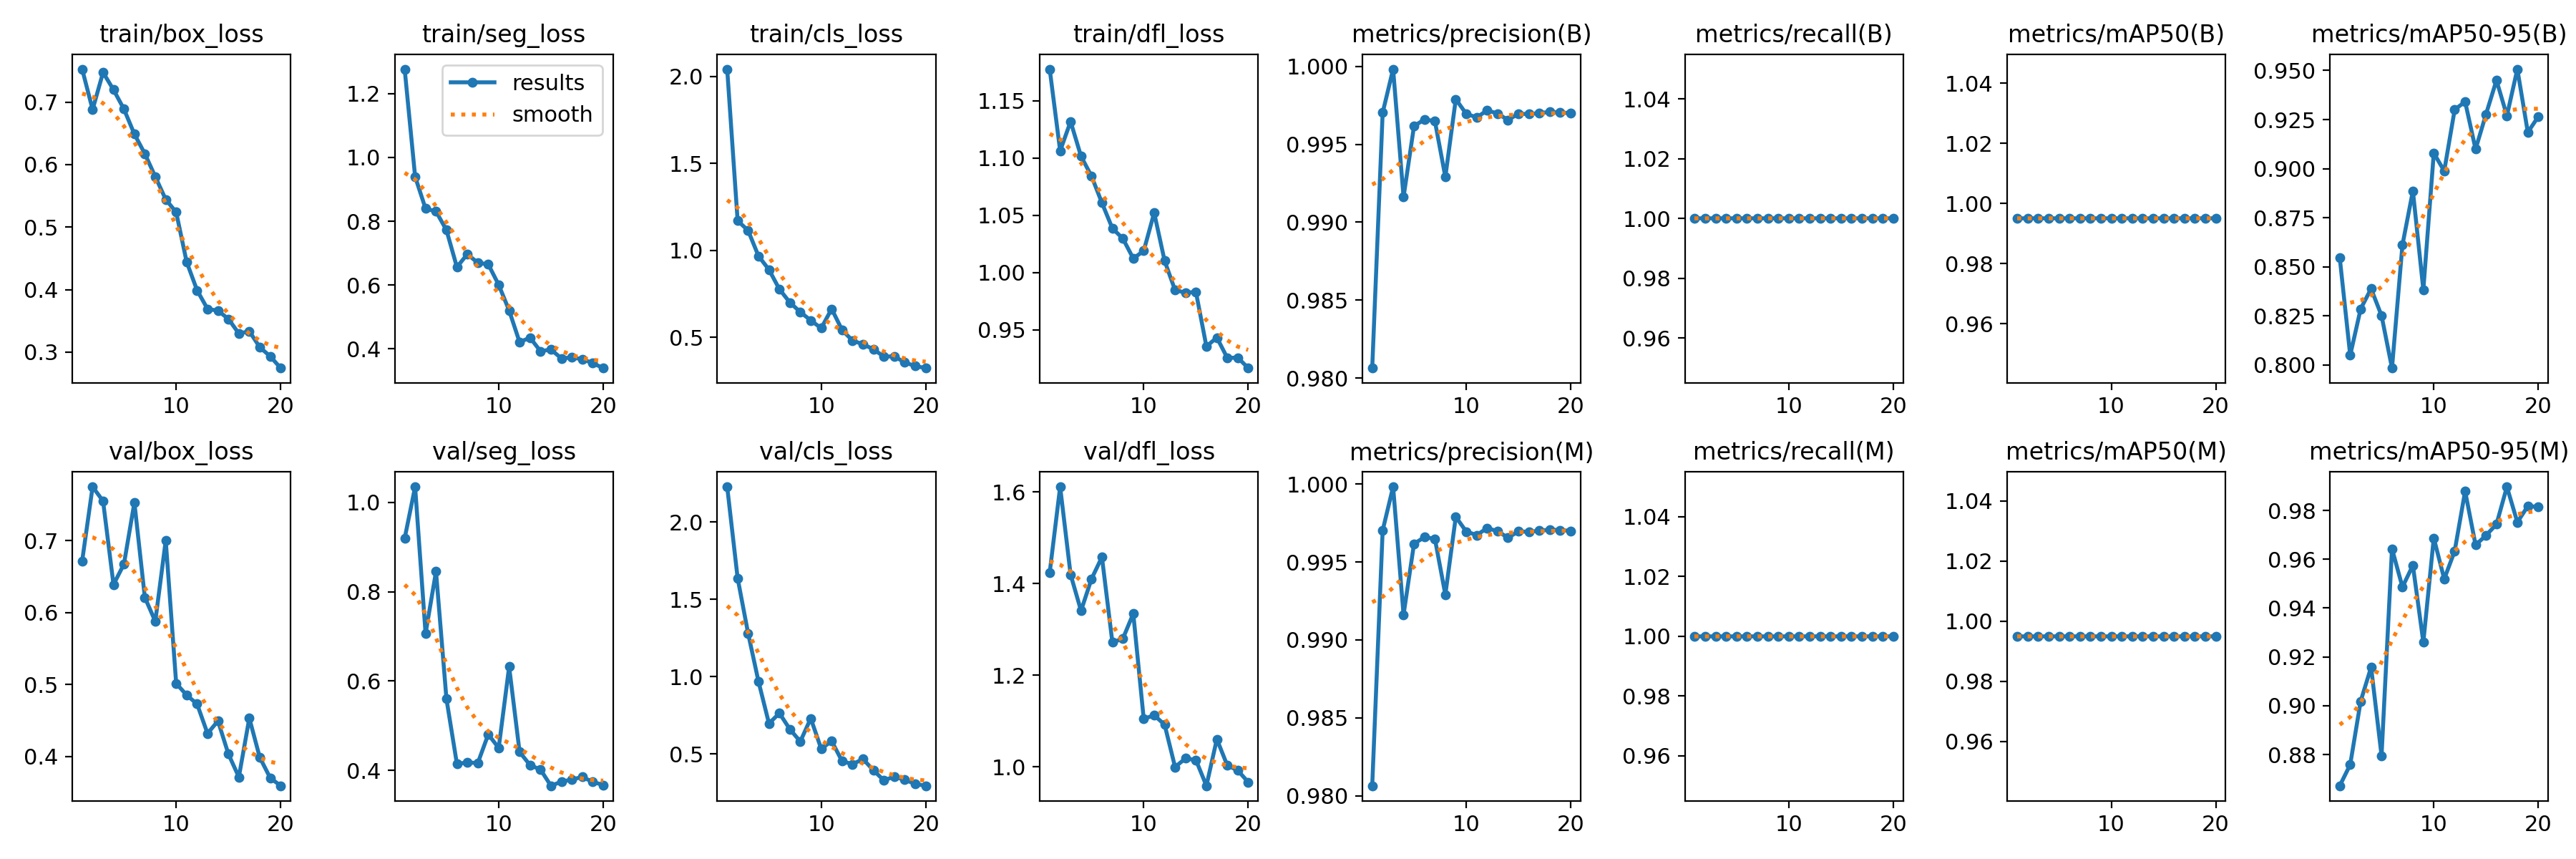

In [ ]:
Image(filename=f'/content/runs/segment/train/results.png', width=1200)

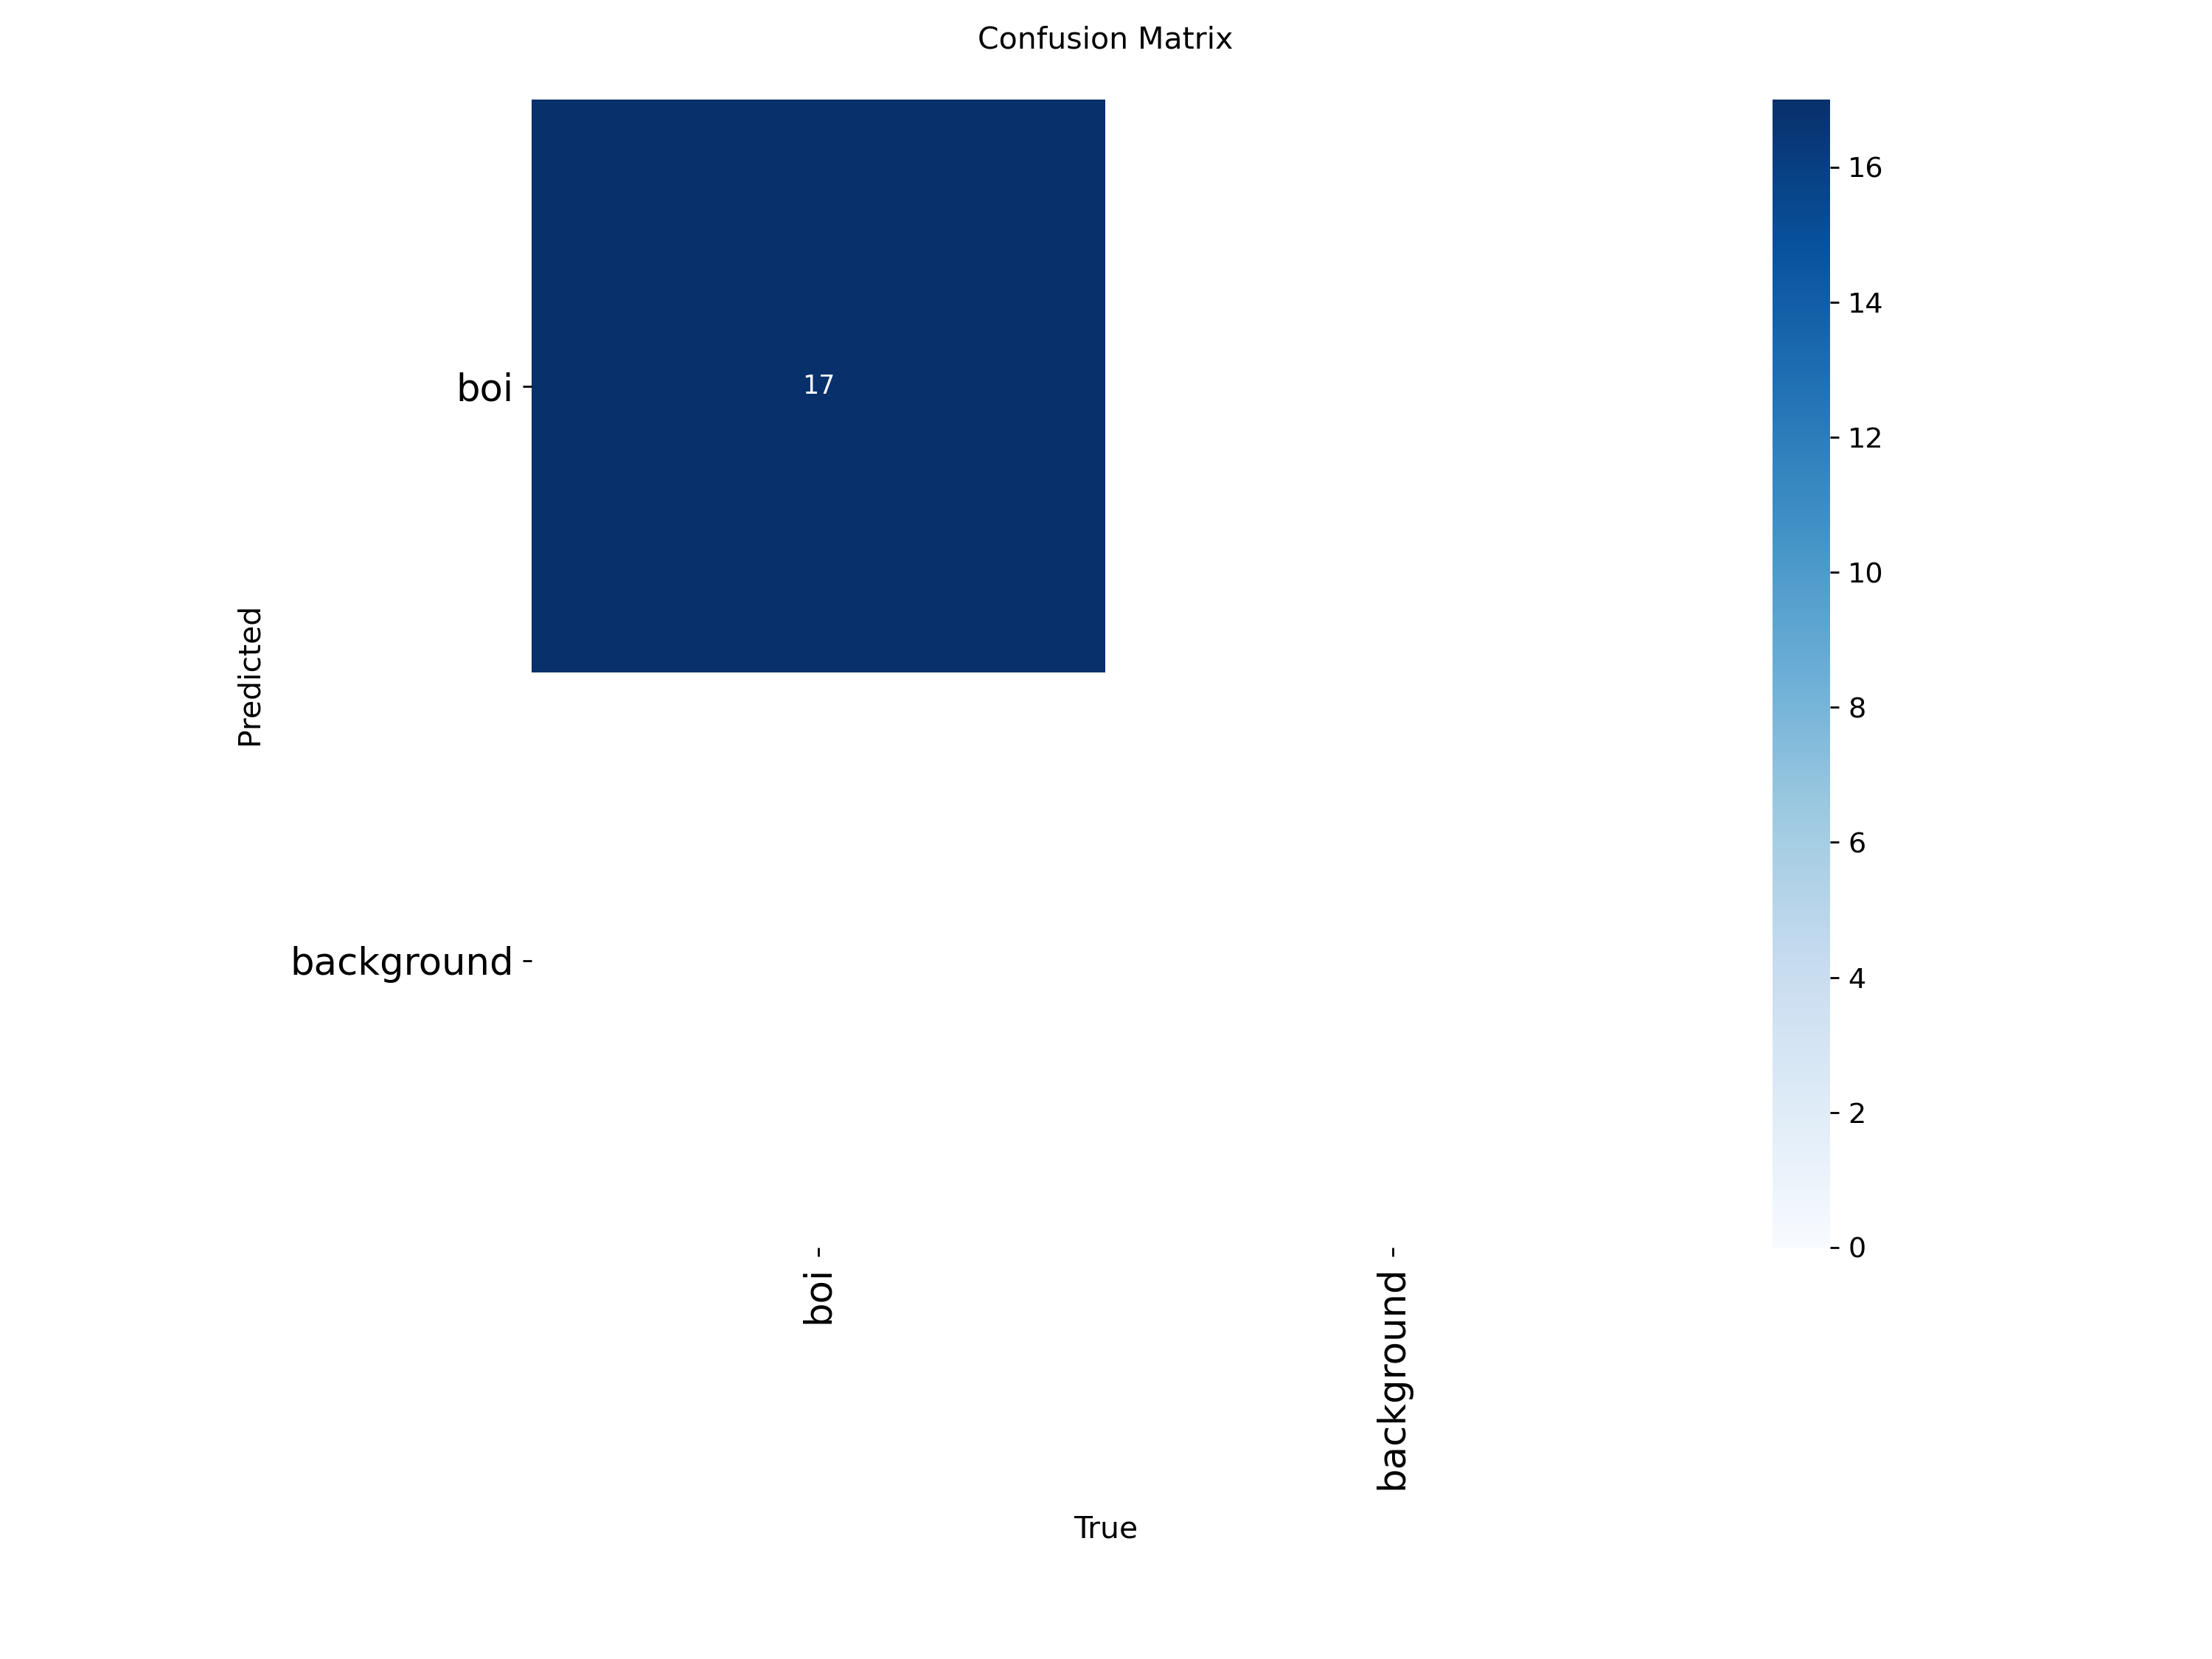

In [ ]:
# Lembre-se de ajustar o número da pasta 'train' para o da sua última execução.
Image(filename=f'/content/runs/segment/train/confusion_matrix.png', width=1200)

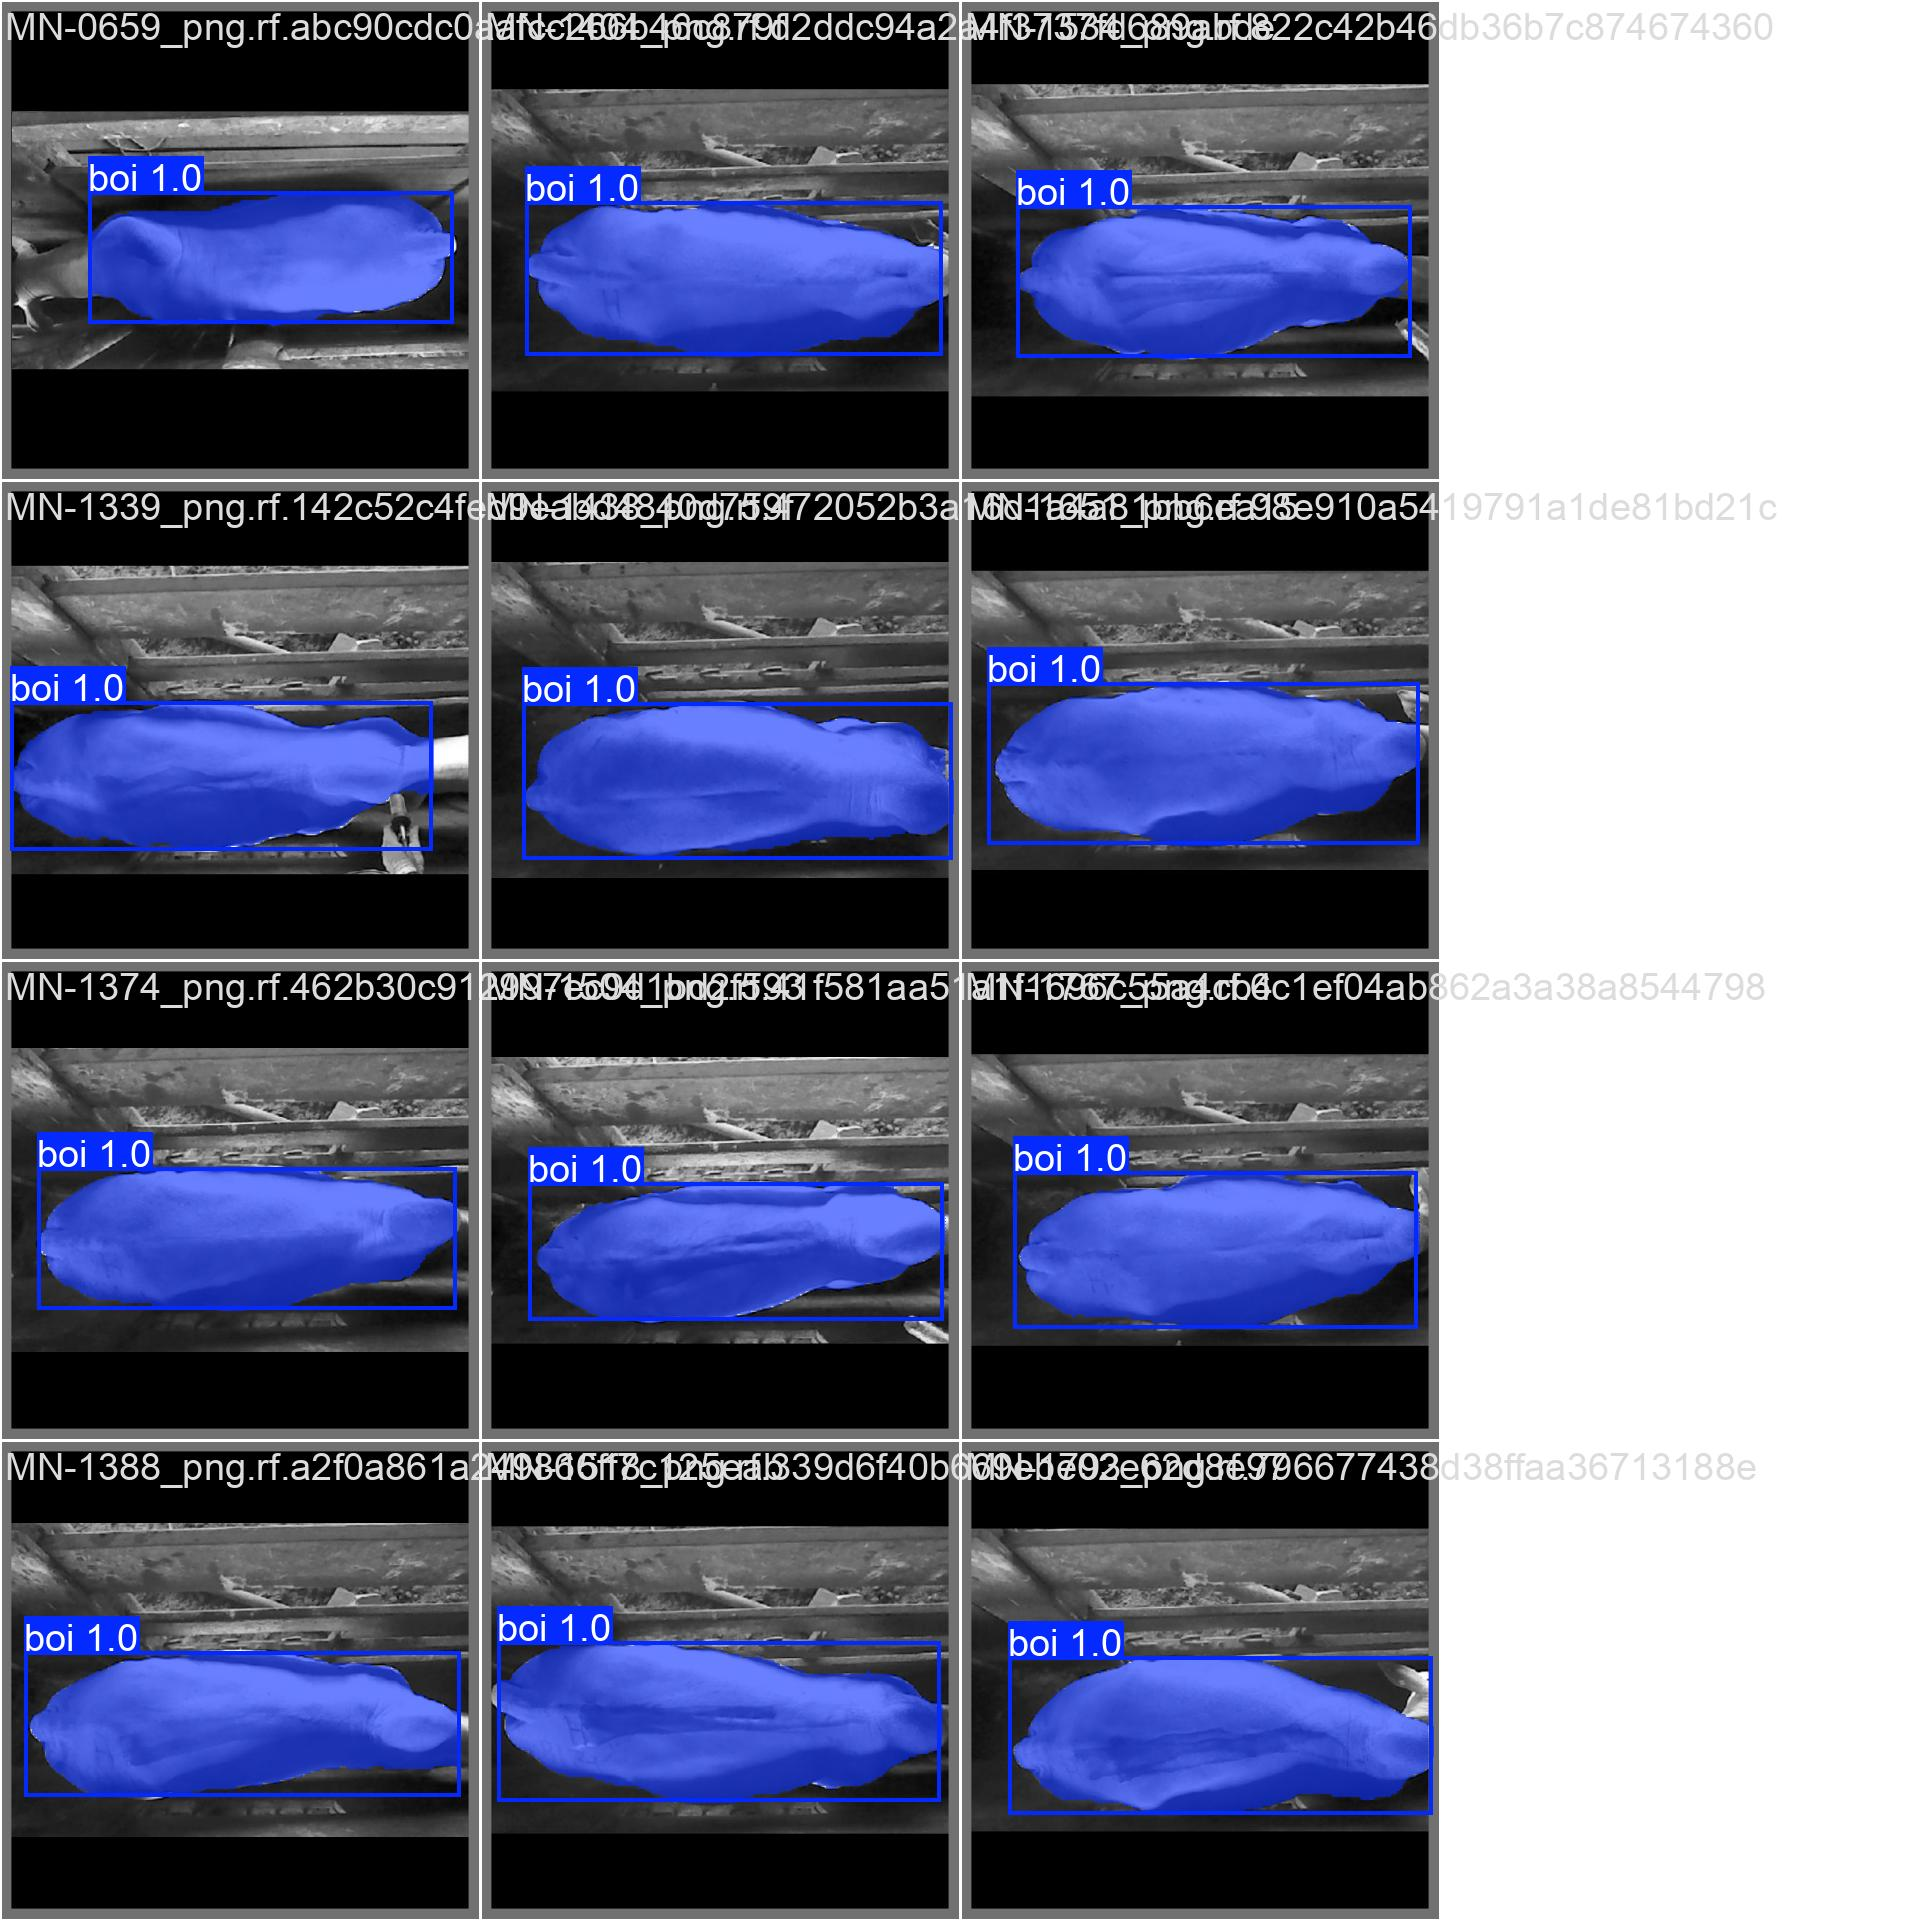

In [ ]:
# Lembre-se de ajustar o número da pasta 'train' para o da sua última execução.
Image(filename=f'/content/runs/segment/train/val_batch0_pred.jpg', width=1200)

In [ ]:
!yolo task=segment mode=val model=/content/runs/segment/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11n-seg summary (fused): 113 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1388.6±295.9 MB/s, size: 31.2 KB)
val: Scanning /content/SegmentacaoBoi-4/valid/labels.cache... 17 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17/17 304.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.6it/s 0.8s
                   all         17         17      0.997          1      0.995      0.943      0.997          1      0.995      0.975
Speed: 4.2ms preprocess, 16.3ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/segment/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
from ultralytics import YOLO

# 1. Carregue o seu modelo treinado (o "cérebro")
model = YOLO("/content/runs/segment/train/weights/best.pt")

# 2. Rode a validação.
# Ele "lembra" o dataset que usou no treino (data.yaml)
print("Iniciando a validação oficial do YOLO...")
metrics = model.val(data="/content/SegmentacaoBoi-4/data.yaml")  # É sempre bom ser explícito com os dados
print("Validação concluída.")

# 3. Extraia e imprima as métricas de SEGMENTAÇÃO (mask)

print("\n" + "="*30)
print("======= MÉTRICAS DE PERFORMANCE (MASK) =======")

# (c) mAP@50
print(f"mAP@50: {metrics.seg.map50:.4f}")

# (d) mAP@50-95
print(f"mAP@50-95: {metrics.seg.map:.4f}")

# (a) Precision
print(f"Precision: {metrics.seg.p[0]:.4f}") # O [0] acessa a métrica 'all'

# (b) Recall
print(f"Recall: {metrics.seg.r[0]:.4f}") # O [0] acessa a métrica 'all'

print("="*30)

Iniciando a validação oficial do YOLO...
Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11n-seg summary (fused): 113 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1269.8±481.2 MB/s, size: 31.2 KB)
val: Scanning /content/SegmentacaoBoi-4/valid/labels.cache... 17 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17/17 37.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.6it/s 0.8s
                   all         17         17      0.997          1      0.995      0.943      0.997          1      0.995      0.975
Speed: 4.2ms preprocess, 16.5ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/segment/val2
Validação concluída.

======= MÉTRICAS DE PERFORMANCE (MASK) =======
mAP@50: 0.9950
mAP@50-95: 0.9751
Precision: 0.9971
Recall: 1.0000


In [ ]:
!yolo task=segment mode=predict model=/content/runs/segment/train/weights/best.pt conf=0.5 source={dataset.location}/test/images

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11n-seg summary (fused): 113 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs

image 1/17 /content/SegmentacaoBoi-4/test/images/MN-0266_png.rf.e6b407bc36aa9a169f6c59dcebd93de1.jpg: 640x640 1 boi, 11.6ms
image 2/17 /content/SegmentacaoBoi-4/test/images/MN-0276_png.rf.03d14ed114dd42656624808eb873dc91.jpg: 640x640 1 boi, 10.6ms
image 3/17 /content/SegmentacaoBoi-4/test/images/MN-0349_png.rf.dc36f8fa5b2ce4729315b69fc63dda74.jpg: 640x640 1 boi, 10.6ms
image 4/17 /content/SegmentacaoBoi-4/test/images/MN-0917_png.rf.f215ff5383f6b785d862b23e27ea356d.jpg: 640x640 1 boi, 10.8ms
image 5/17 /content/SegmentacaoBoi-4/test/images/MN-1393_png.rf.0265ea9baf2df31df5ae74a298eb866e.jpg: 640x640 1 boi, 10.3ms
image 6/17 /content/SegmentacaoBoi-4/test/images/MN-1401_png.rf.44508c4b94b657f57c6611adb210ae1d.jpg: 640x640 1 boi, 10.7ms
image 7/17 /content/SegmentacaoBoi-4/test/images/MN-1448_png.rf.9e72eba58c465fe86442

Exibindo 17 imagens encontradas:


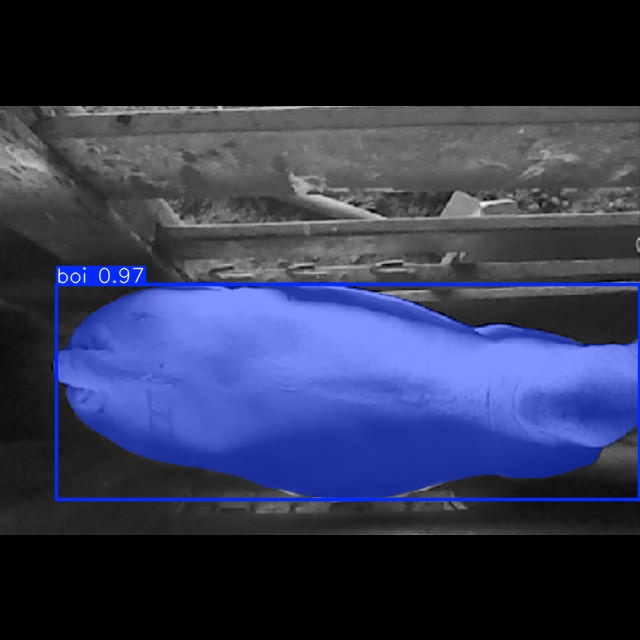

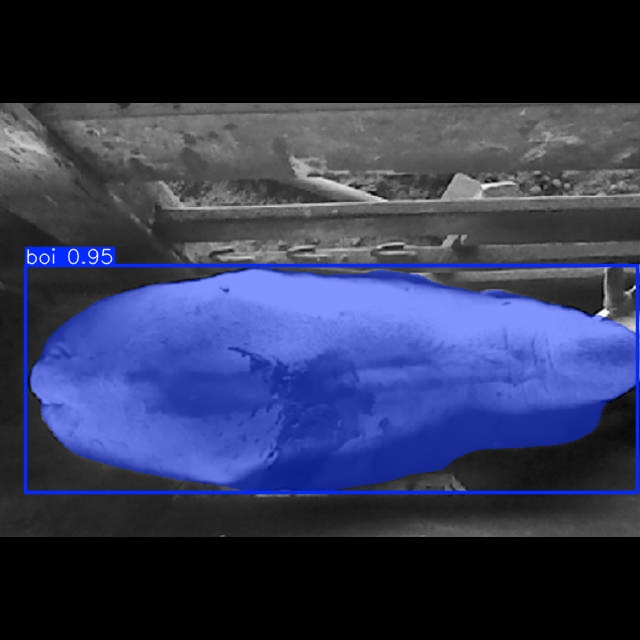

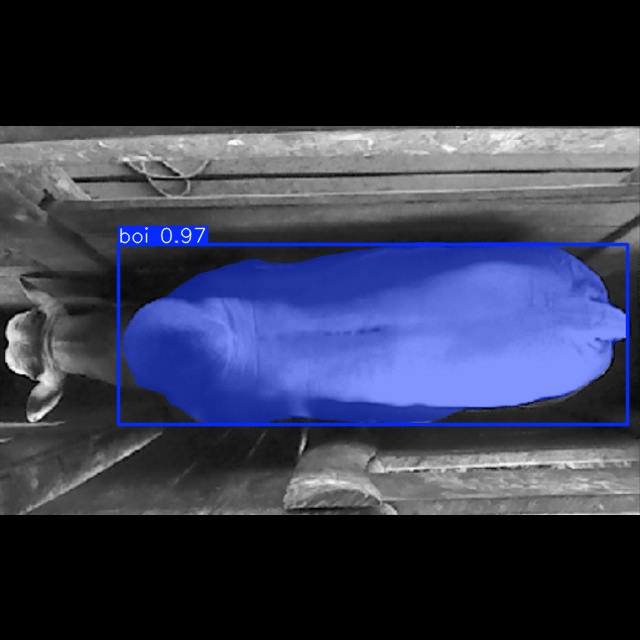

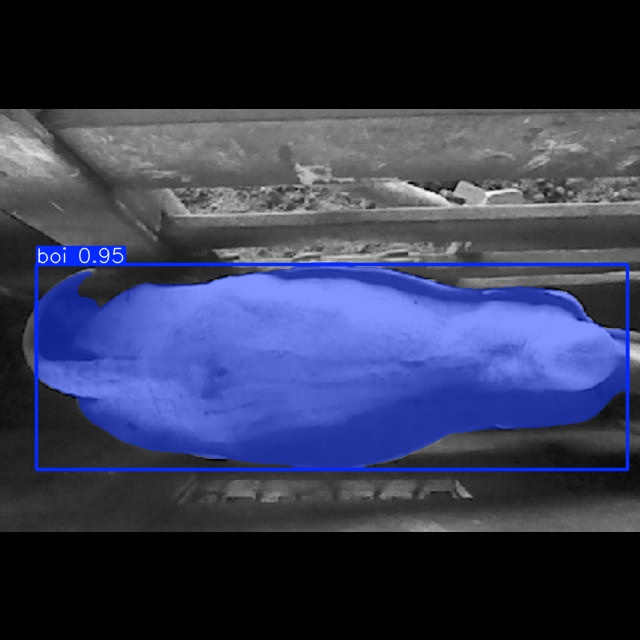

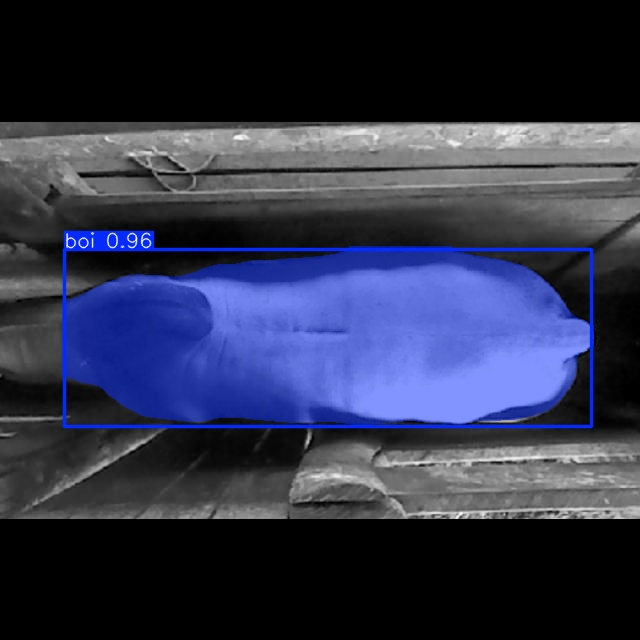

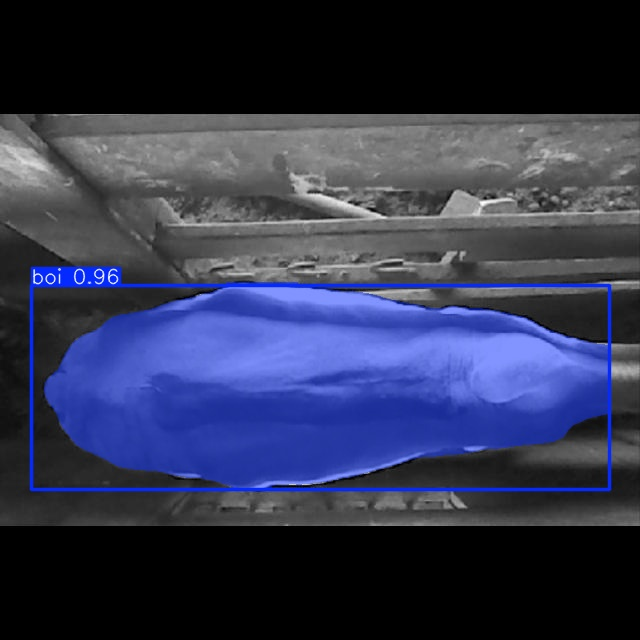

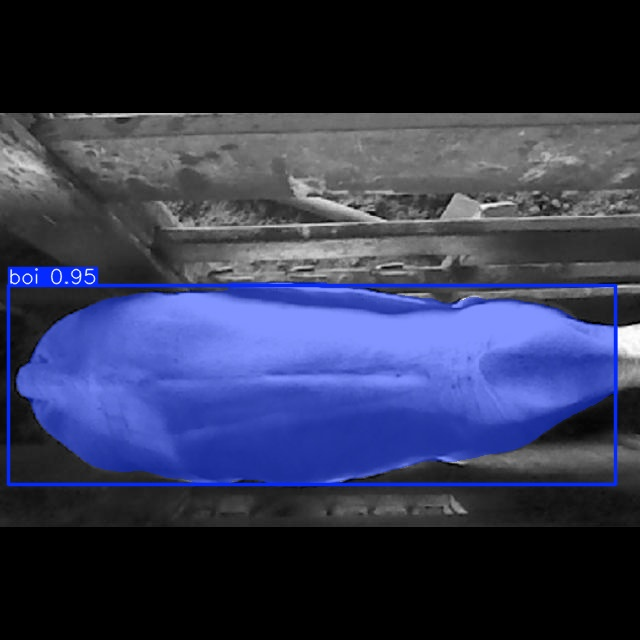

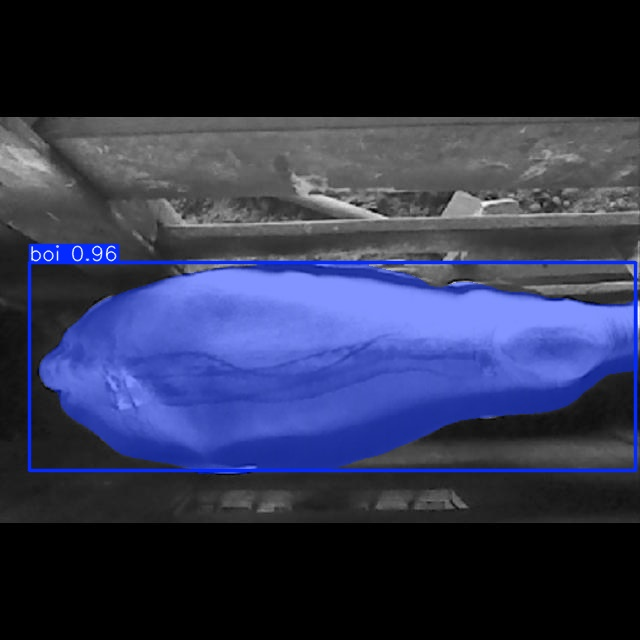

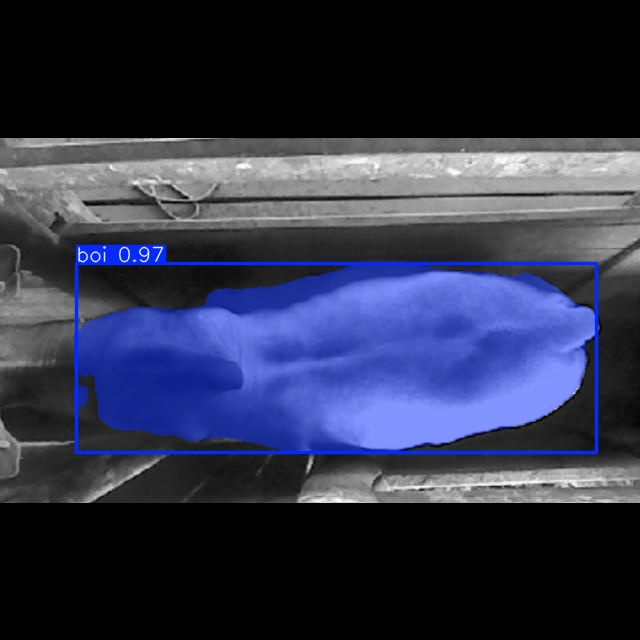

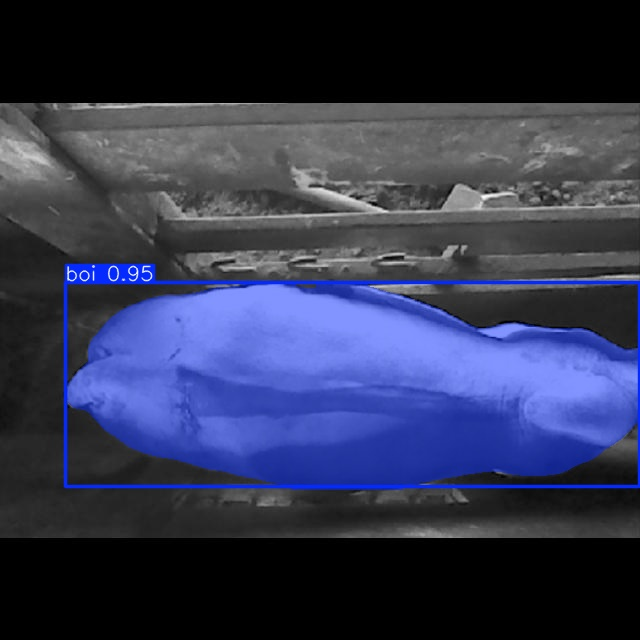

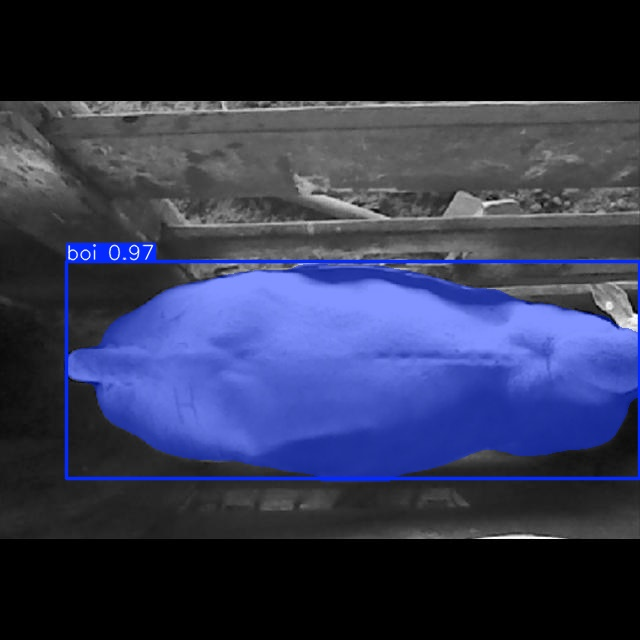

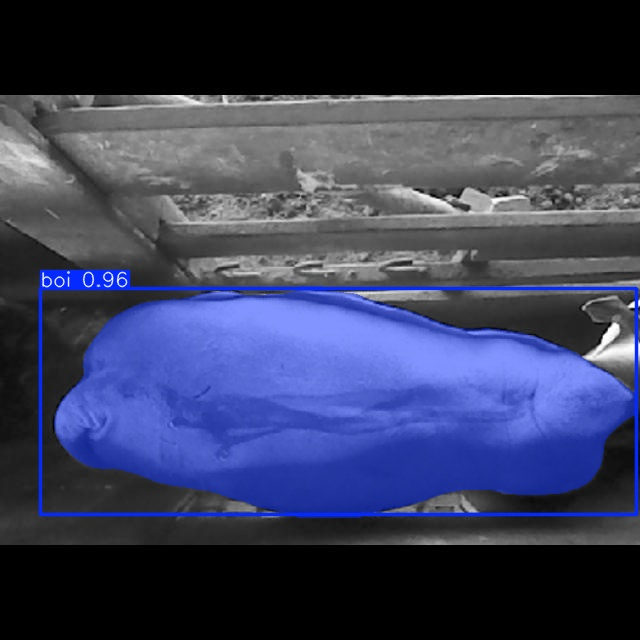

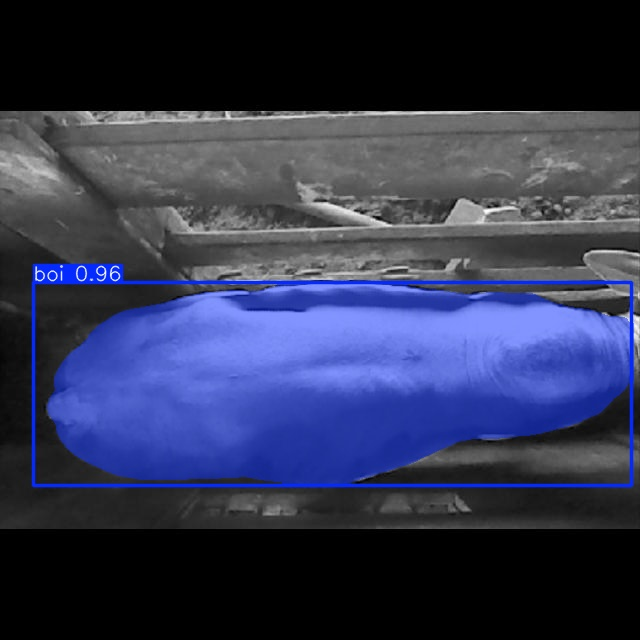

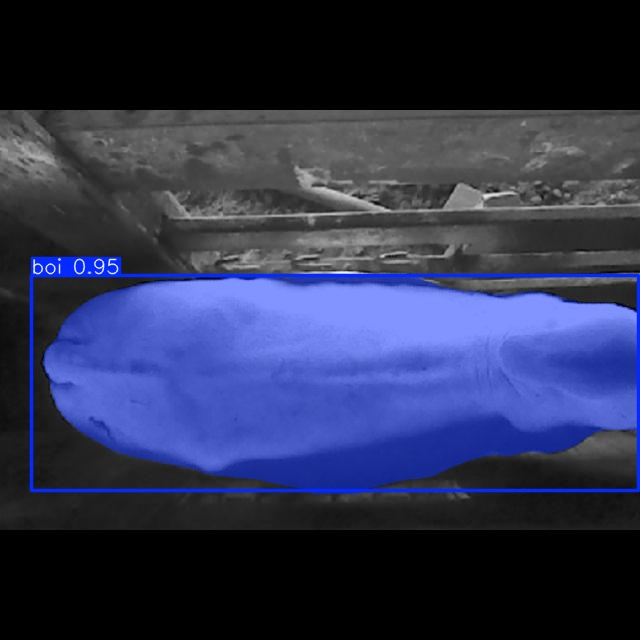

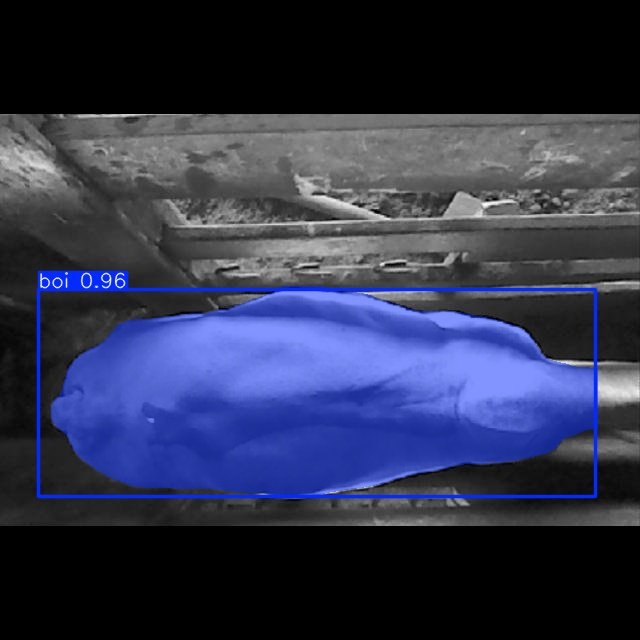

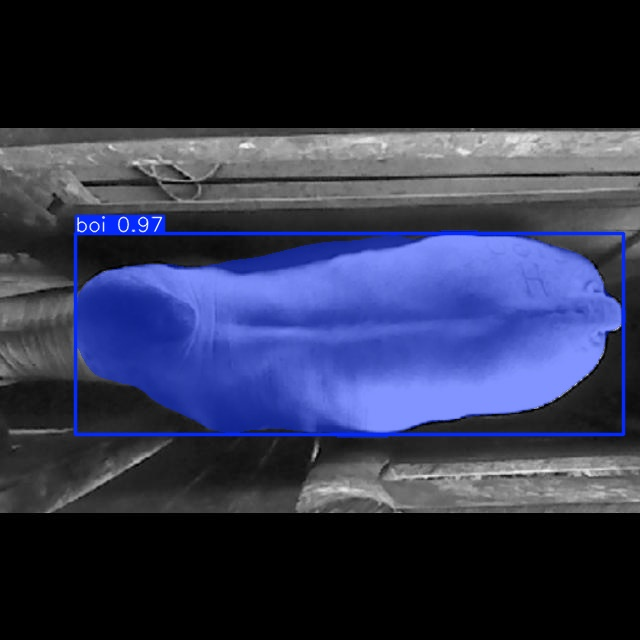

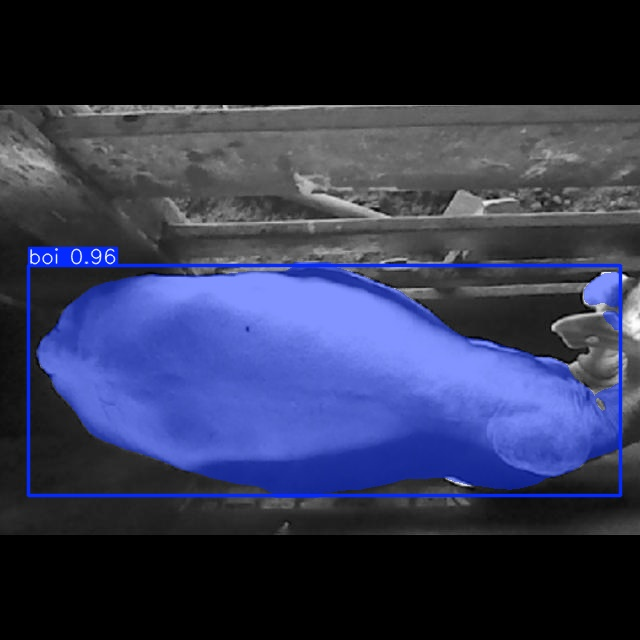

In [ ]:
# CÉLULA DE CÓDIGO 9: VISUALIZAÇÃO (SEGMENTAÇÃO)

import os
from IPython.display import Image, display

# O caminho agora aponta para a pasta de predição de 'segment'
pasta_resultados = '/content/runs/segment/predict/'

if os.path.exists(pasta_resultados):
    imagens_encontradas = [arq for arq in os.listdir(pasta_resultados) if arq.lower().endswith(('.jpg', '.png', '.jpeg'))]
    print(f"Exibindo {len(imagens_encontradas)} imagens encontradas:")
    for nome_imagem in imagens_encontradas:
        caminho_completo = os.path.join(pasta_resultados, nome_imagem)
        display(Image(filename=caminho_completo, width=600))
        print("\n")
else:
    print(f"ERRO: A pasta '{pasta_resultados}' não foi encontrada.")

resultados obtidos com: ***batch=6 epochs=20 imgsz=640 plots=True***

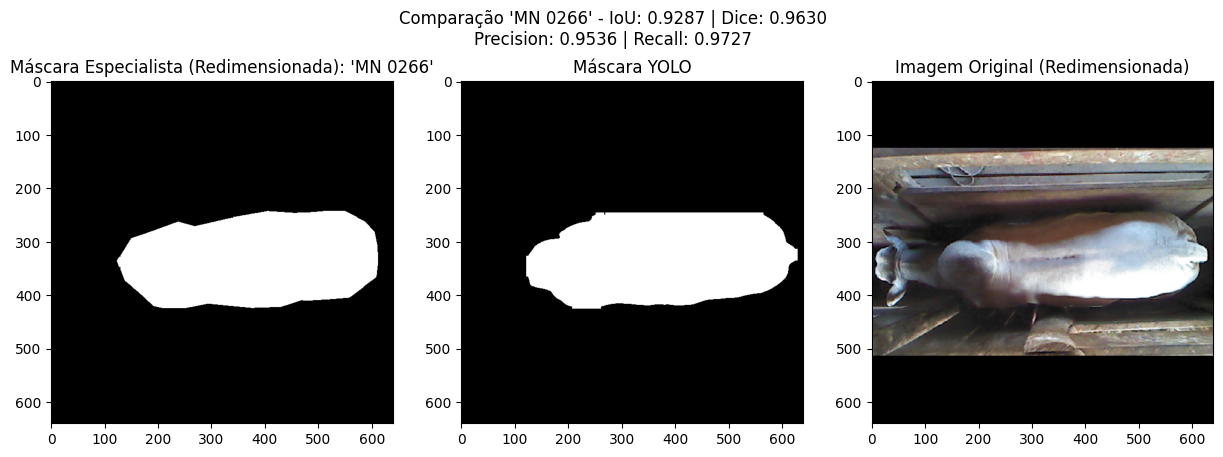


Resultados para 'MN 0266':
  IoU: 0.9287
  Dice (F1): 0.9630
  Precision: 0.9536
  Recall: 0.9727


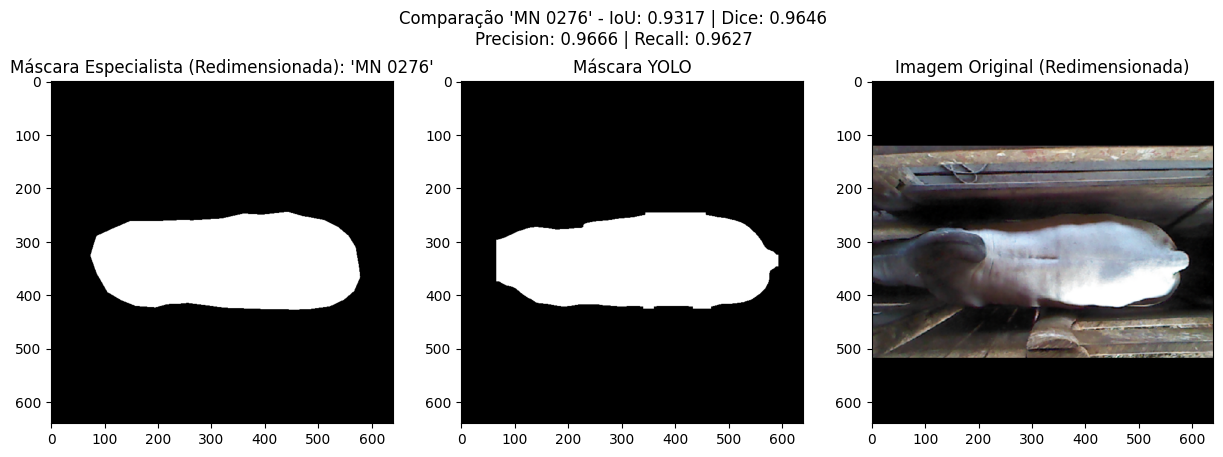


Resultados para 'MN 0276':
  IoU: 0.9317
  Dice (F1): 0.9646
  Precision: 0.9666
  Recall: 0.9627

Aviso: YOLO não detectou nada em 'MN 0349'. Métricas serão 0.


Resultados para 'MN 0349':
  IoU: 0.0000
  Dice (F1): 0.0000
  Precision: 0.0000
  Recall: 0.0000


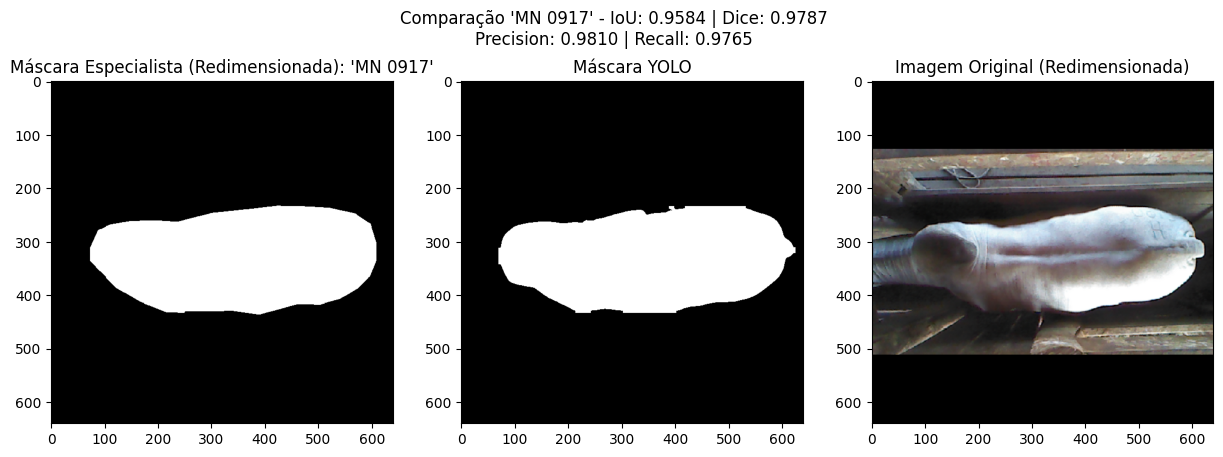


Resultados para 'MN 0917':
  IoU: 0.9584
  Dice (F1): 0.9787
  Precision: 0.9810
  Recall: 0.9765


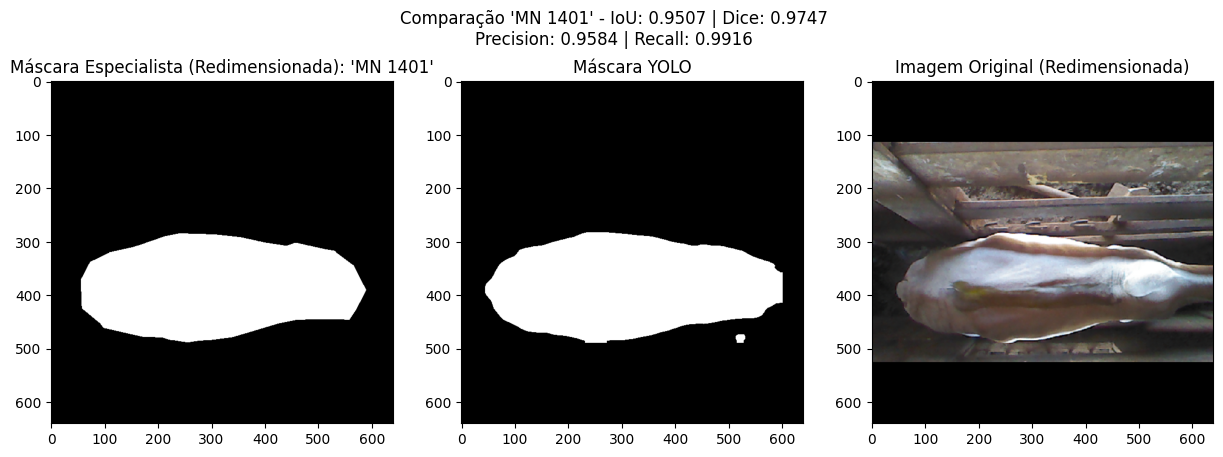


Resultados para 'MN 1401':
  IoU: 0.9507
  Dice (F1): 0.9747
  Precision: 0.9584
  Recall: 0.9916


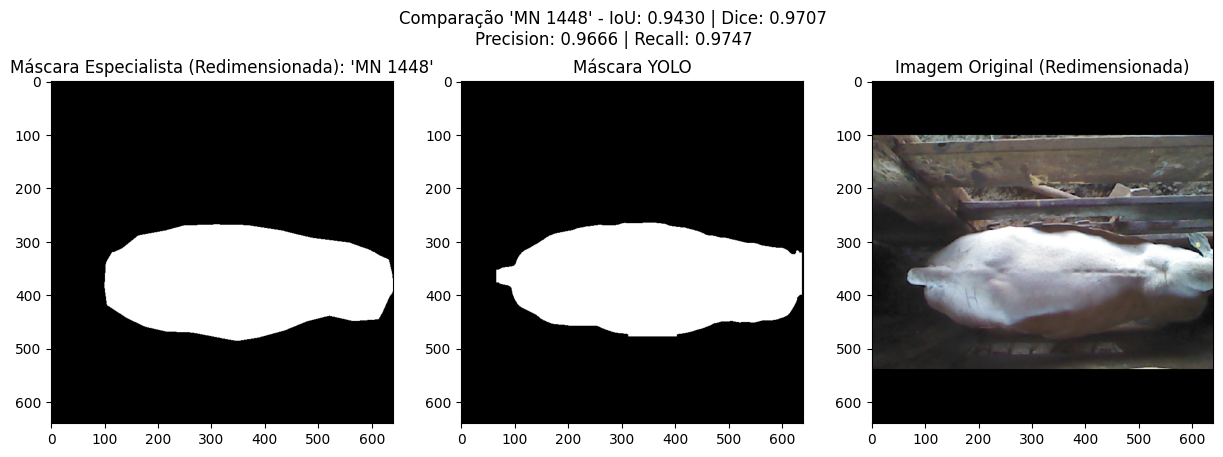


Resultados para 'MN 1448':
  IoU: 0.9430
  Dice (F1): 0.9707
  Precision: 0.9666
  Recall: 0.9747


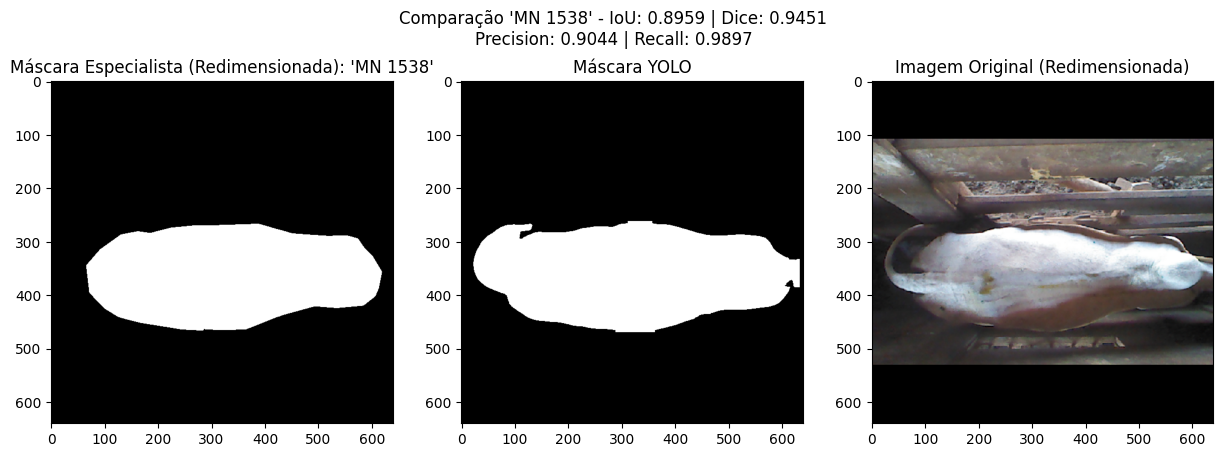


Resultados para 'MN 1538':
  IoU: 0.8959
  Dice (F1): 0.9451
  Precision: 0.9044
  Recall: 0.9897


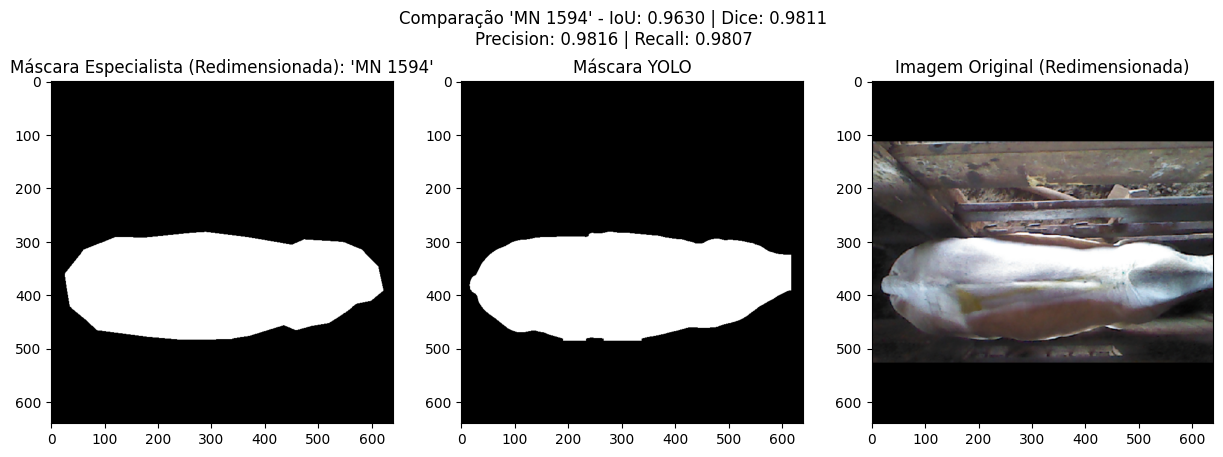


Resultados para 'MN 1594':
  IoU: 0.9630
  Dice (F1): 0.9811
  Precision: 0.9816
  Recall: 0.9807


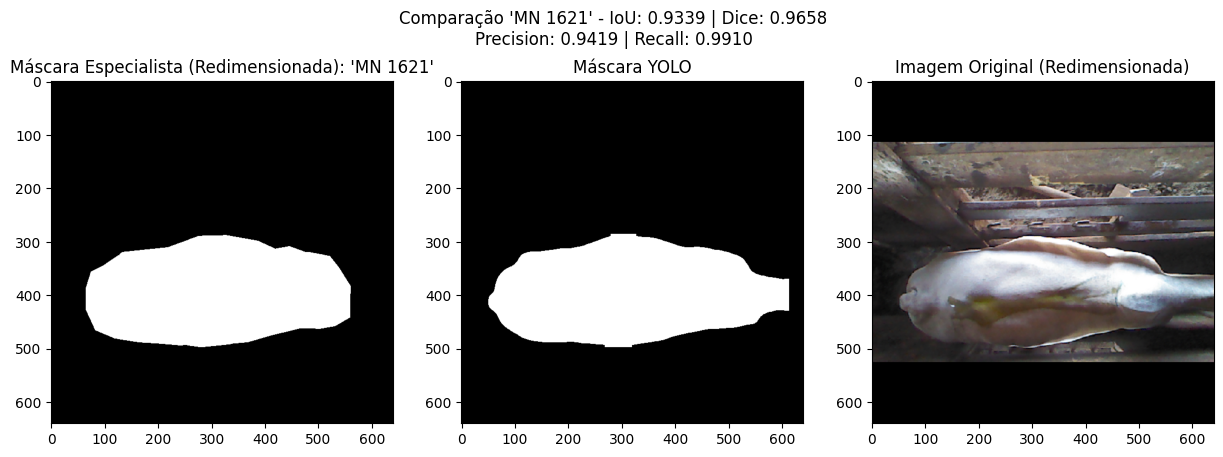


Resultados para 'MN 1621':
  IoU: 0.9339
  Dice (F1): 0.9658
  Precision: 0.9419
  Recall: 0.9910


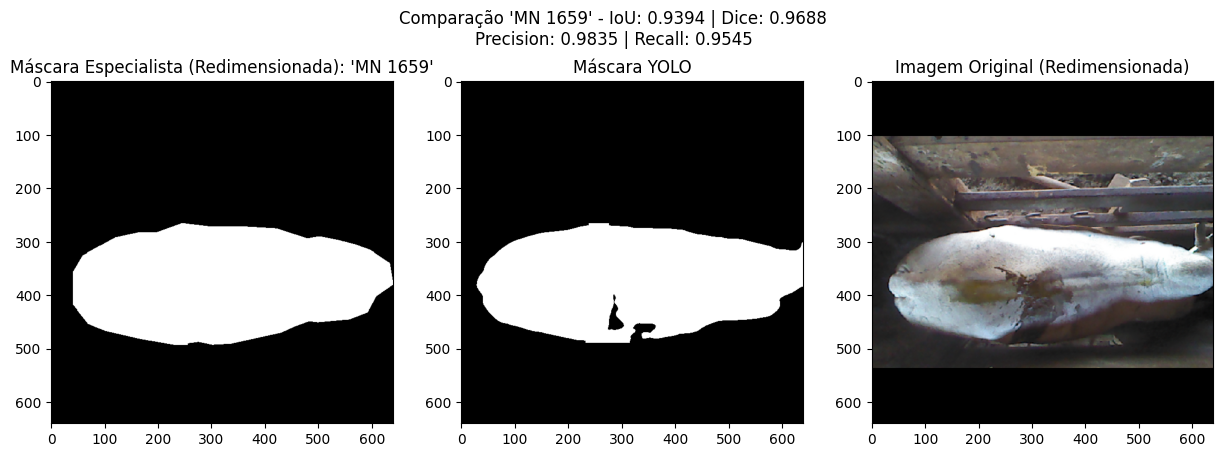


Resultados para 'MN 1659':
  IoU: 0.9394
  Dice (F1): 0.9688
  Precision: 0.9835
  Recall: 0.9545


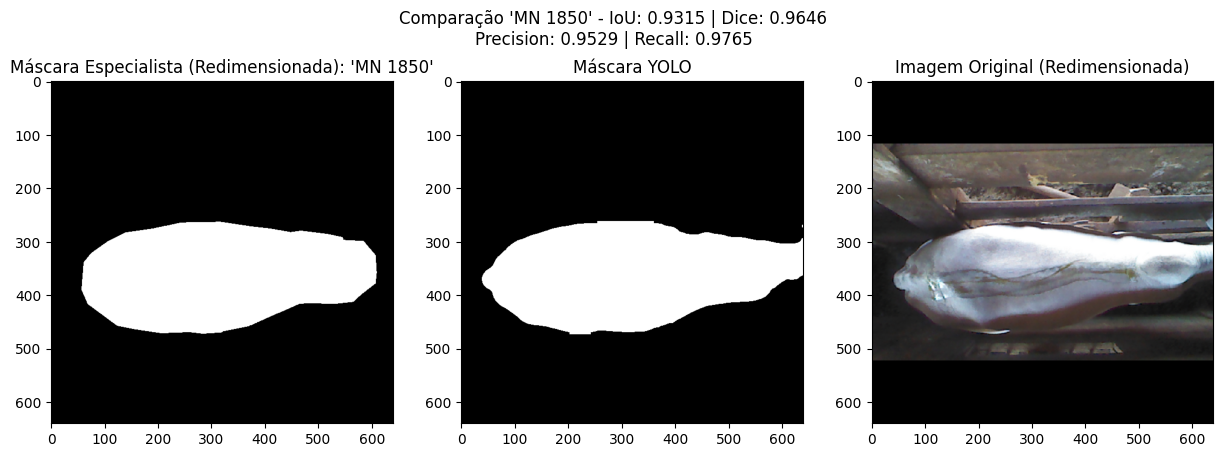


Resultados para 'MN 1850':
  IoU: 0.9315
  Dice (F1): 0.9646
  Precision: 0.9529
  Recall: 0.9765


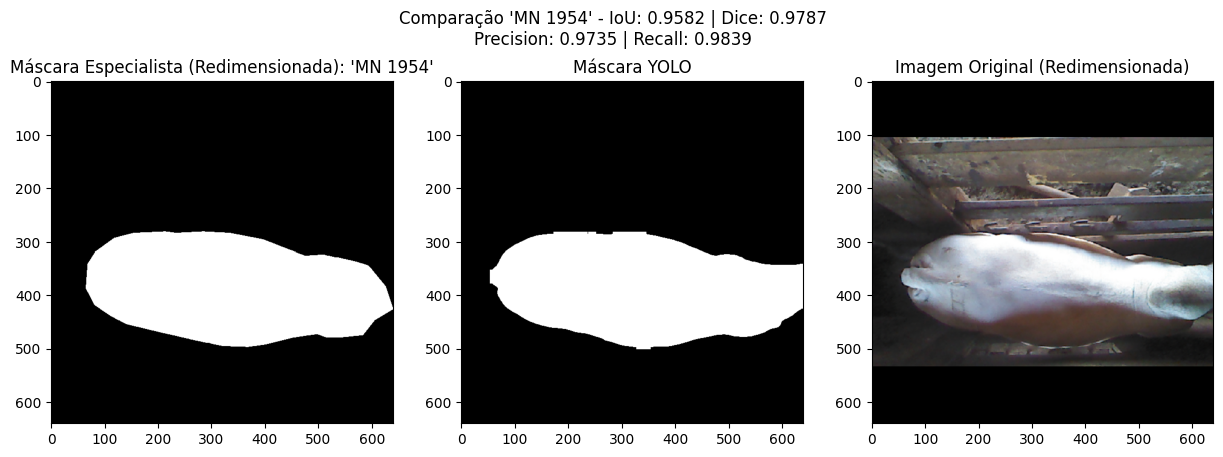


Resultados para 'MN 1954':
  IoU: 0.9582
  Dice (F1): 0.9787
  Precision: 0.9735
  Recall: 0.9839


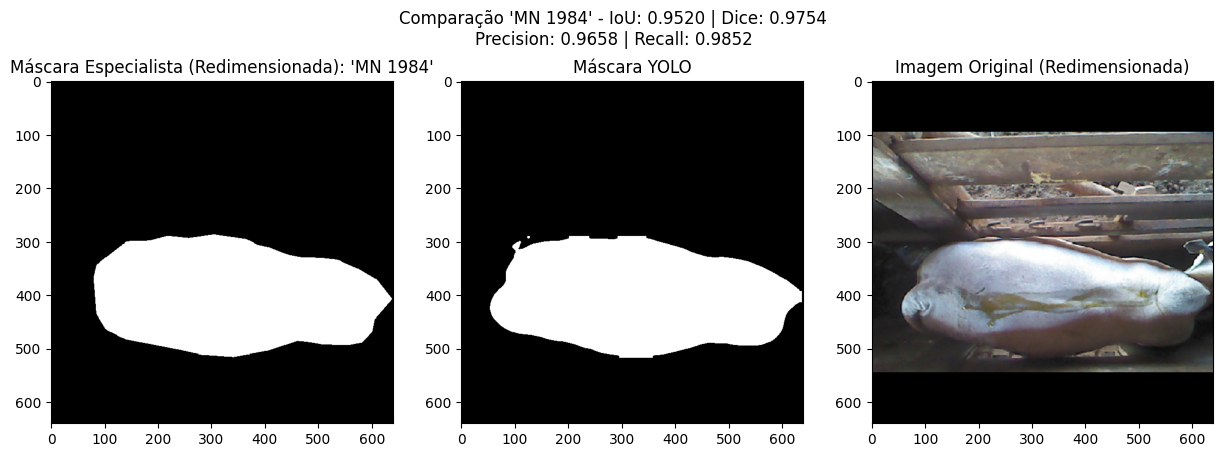


Resultados para 'MN 1984':
  IoU: 0.9520
  Dice (F1): 0.9754
  Precision: 0.9658
  Recall: 0.9852


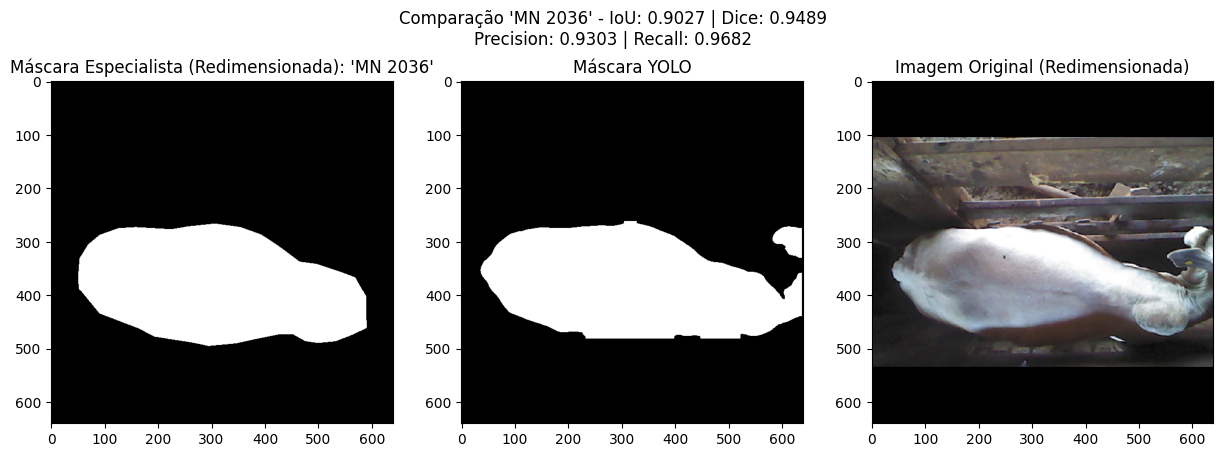


Resultados para 'MN 2036':
  IoU: 0.9027
  Dice (F1): 0.9489
  Precision: 0.9303
  Recall: 0.9682


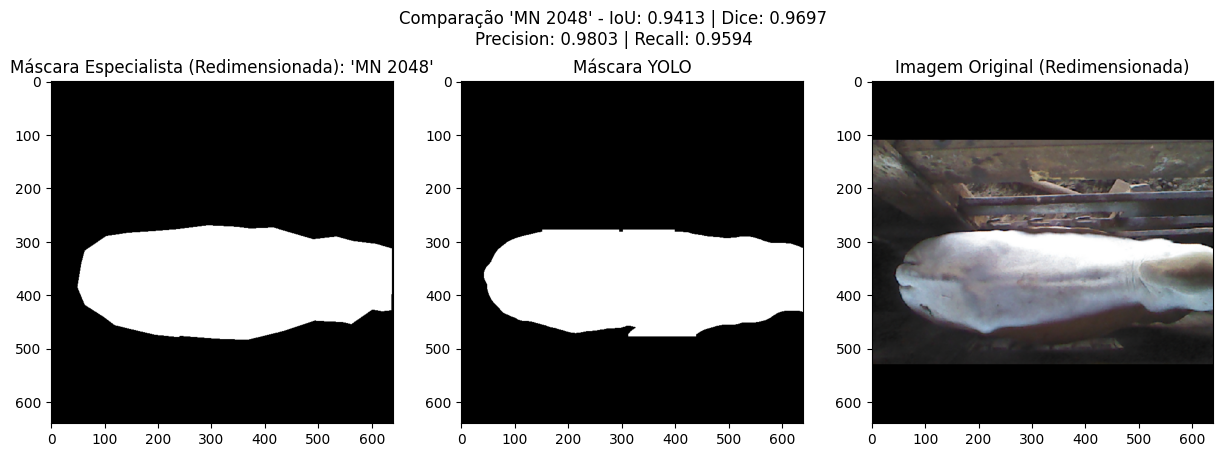


Resultados para 'MN 2048':
  IoU: 0.9413
  Dice (F1): 0.9697
  Precision: 0.9803
  Recall: 0.9594

======= MÉDIAS FINAIS DE PERFORMANCE =======
MÉDIA FINAL DO IOU: 0.8754
MÉDIA FINAL DO DICE (F1-SCORE): 0.9033
MÉDIA FINAL DA PRECISÃO: 0.8960
MÉDIA FINAL DO RECALL: 0.9111


In [ ]:
import os
import glob
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

# --- FUNÇÕES DE AJUDA ---
def criar_mascara_do_png_especialista(caminho_imagem_png):
    imagem = cv2.imread(caminho_imagem_png, cv2.IMREAD_UNCHANGED)
    if imagem is None: return None
    canal_alfa = imagem[:, :, 3]
    _, mascara_binaria = cv2.threshold(canal_alfa, 0, 255, cv2.THRESH_BINARY)
    return mascara_binaria

def redimensionar_com_padding(imagem, tamanho_final=(640, 640)):
    h, w = imagem.shape[:2]
    escala = min(tamanho_final[0] / w, tamanho_final[1] / h)
    novo_w, novo_h = int(w * escala), int(h * escala)
    imagem_redimensionada = cv2.resize(imagem, (novo_w, novo_h), interpolation=cv2.INTER_NEAREST)
    if len(imagem.shape) == 3:
        imagem_final = np.zeros((tamanho_final[1], tamanho_final[0], 3), dtype=np.uint8)
    else:
        imagem_final = np.zeros(tamanho_final, dtype=np.uint8)
    top = (tamanho_final[1] - novo_h) // 2
    left = (tamanho_final[0] - novo_w) // 2
    imagem_final[top:top+novo_h, left:left+novo_w] = imagem_redimensionada
    return imagem_final

#FUNÇÃO ÚNICA PARA TODAS AS MÉTRICAS
def calcular_metricas_segmentacao(mascara_verdadeira, mascara_predita):
    """
    Calcula IoU, Dice (F1), Precisão e Recall para máscaras de segmentação.
    """
    mascara_verdadeira_bool = mascara_verdadeira.astype(bool)
    mascara_predita_bool = mascara_predita.astype(bool)

    # Calcular os componentes básicos
    tp = np.sum(np.logical_and(mascara_verdadeira_bool, mascara_predita_bool)) # Verdadeiro Positivo
    fp = np.sum(np.logical_and(np.logical_not(mascara_verdadeira_bool), mascara_predita_bool)) # Falso Positivo
    fn = np.sum(np.logical_and(mascara_verdadeira_bool, np.logical_not(mascara_predita_bool))) # Falso Negativo

    # 1. Calcular IoU (Intersection over Union)
    uniao = tp + fp + fn
    iou = tp / uniao if uniao > 0 else 0.0

    # 2. Calcular Precisão (Precision)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    # 3. Calcular Recall (Sensibilidade)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    # 4. Calcular Dice Coefficient (F1-Score)
    dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0

    return {'iou': iou, 'dice': dice, 'precision': precision, 'recall': recall}

# --- CONFIGURAÇÃO ---
model = YOLO('/content/runs/segment/train/weights/best.pt')
caminho_imagens_originais = "/content/drive/MyDrive/imagens boi/original/teste"
caminho_mascaras_especialista = "/content/drive/MyDrive/imagens boi/segmentadas sem fundo/teste"
imagens_originais_paths = sorted(glob.glob(os.path.join(caminho_imagens_originais, "*.*")))

# --- LOOP PRINCIPAL ---
iou_scores = []
dice_scores = []
precision_scores = []
recall_scores = []
resultados = {}

for caminho_img_original in imagens_originais_paths:
    nome_base = os.path.splitext(os.path.basename(caminho_img_original))[0]
    caminho_png_especialista = os.path.join(caminho_mascaras_especialista, f"{nome_base}.png")
    if not os.path.exists(caminho_png_especialista):
        continue

    mascara_especialista_original = criar_mascara_do_png_especialista(caminho_png_especialista)
    mascara_especialista_final = redimensionar_com_padding(mascara_especialista_original)

    results = model.predict(caminho_img_original, imgsz=640, verbose=False)

    # Se o YOLO não detectar nada, todas as métricas são 0 (exceto Precisão, que pode ser 0 ou indefinida)
    if results[0].masks is None or len(results[0].masks.data) == 0:
        print("")
        print(f"Aviso: YOLO não detectou nada em '{nome_base}'. Métricas serão 0.")
        print("")
        metricas = {'iou': 0.0, 'dice': 0.0, 'precision': 0.0, 'recall': 0.0}
    else:
        all_masks_raw = results[0].masks.data.cpu().numpy()
        merged_mask_raw = np.logical_or.reduce(all_masks_raw, axis=0).astype(np.uint8) * 255
        mascara_yolo_final = redimensionar_com_padding(merged_mask_raw)

        #Chama a nova função que calcula tudo de uma vez
        metricas = calcular_metricas_segmentacao(mascara_especialista_final, mascara_yolo_final)

        # Plotagem dentro do loop
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(mascara_especialista_final, cmap='gray')
        plt.title(f"Máscara Especialista (Redimensionada): '{nome_base}'")
        plt.axis('on')
        plt.subplot(1, 3, 2)
        plt.imshow(mascara_yolo_final, cmap='gray')
        plt.title("Máscara YOLO")
        plt.axis('on')

        img_original_plot_individual = cv2.cvtColor(cv2.imread(caminho_img_original), cv2.COLOR_BGR2RGB)
        img_original_plot_individual_resized = redimensionar_com_padding(img_original_plot_individual)
        plt.subplot(1, 3, 3)
        plt.imshow(img_original_plot_individual_resized)
        plt.title("Imagem Original (Redimensionada)")
        plt.axis('on')

        #Atualiza o título do gráfico para mostrar as novas métricas
        titulo_plot = (
            f"Comparação '{nome_base}' - IoU: {metricas['iou']:.4f} | Dice: {metricas['dice']:.4f}\n"
            f"Precision: {metricas['precision']:.4f} | Recall: {metricas['recall']:.4f}"
        )
        plt.suptitle(titulo_plot)
        plt.show()

    #Adiciona todas as novas métricas às suas listas
    iou_scores.append(metricas['iou'])
    dice_scores.append(metricas['dice'])
    precision_scores.append(metricas['precision'])
    recall_scores.append(metricas['recall'])

    resultados[nome_base] = metricas

    #Atualiza o print do console
    print("\n" + "="*30)
    print(f"Resultados para '{nome_base}':")
    print(f"  IoU: {metricas['iou']:.4f}")
    print(f"  Dice (F1): {metricas['dice']:.4f}")
    print(f"  Precision: {metricas['precision']:.4f}")
    print(f"  Recall: {metricas['recall']:.4f}")
    print("="*30)

# --- RESULTADO FINAL ---
#Calcula e exibe a média de todas as métricas
if iou_scores:
    media_iou = np.mean(iou_scores)
    media_dice = np.mean(dice_scores)
    media_precision = np.mean(precision_scores)
    media_recall = np.mean(recall_scores)

    print("\n" + "="*40)
    print("======= MÉDIAS FINAIS DE PERFORMANCE =======")
    print("="*40)
    print(f"MÉDIA FINAL DO IOU: {media_iou:.4f}")
    print(f"MÉDIA FINAL DO DICE (F1-SCORE): {media_dice:.4f}")
    print(f"MÉDIA FINAL DA PRECISÃO: {media_precision:.4f}")
    print(f"MÉDIA FINAL DO RECALL: {media_recall:.4f}")
    print("="*40)

In [ ]:
import os
import glob
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

# --- FUNÇÕES DE AJUDA ---
def criar_mascara_do_png_especialista(caminho_imagem_png):
    imagem = cv2.imread(caminho_imagem_png, cv2.IMREAD_UNCHANGED)
    if imagem is None: return None
    canal_alfa = imagem[:, :, 3]
    _, mascara_binaria = cv2.threshold(canal_alfa, 0, 255, cv2.THRESH_BINARY)
    return mascara_binaria

def redimensionar_com_padding(imagem, tamanho_final=(640, 640)):
    h, w = imagem.shape[:2]
    escala = min(tamanho_final[0] / w, tamanho_final[1] / h)
    novo_w, novo_h = int(w * escala), int(h * escala)
    imagem_redimensionada = cv2.resize(imagem, (novo_w, novo_h), interpolation=cv2.INTER_NEAREST)
    if len(imagem.shape) == 3:
        imagem_final = np.zeros((tamanho_final[1], tamanho_final[0], 3), dtype=np.uint8)
    else:
        imagem_final = np.zeros(tamanho_final, dtype=np.uint8)
    top = (tamanho_final[1] - novo_h) // 2
    left = (tamanho_final[0] - novo_w) // 2
    imagem_final[top:top+novo_h, left:left+novo_w] = imagem_redimensionada
    return imagem_final

# FUNÇÃO DE MÉTRICAS COM ACCURACY
def calcular_metricas_segmentacao(mascara_verdadeira, mascara_predita):
    mascara_verdadeira_bool = mascara_verdadeira.astype(bool)
    mascara_predita_bool = mascara_predita.astype(bool)

    # Calcular os componentes básicos
    tp = np.sum(np.logical_and(mascara_verdadeira_bool, mascara_predita_bool)) # Verdadeiro Positivo
    fp = np.sum(np.logical_and(np.logical_not(mascara_verdadeira_bool), mascara_predita_bool)) # Falso Positivo
    fn = np.sum(np.logical_and(mascara_verdadeira_bool, np.logical_not(mascara_predita_bool))) # Falso Negativo
    tn = np.sum(np.logical_and(np.logical_not(mascara_verdadeira_bool), np.logical_not(mascara_predita_bool))) # Verdadeiro Negativo

    uniao = tp + fp + fn
    iou = tp / uniao if uniao > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0

    # 5. Calcular Acurácia de Pixel
    total_pixels = tp + tn + fp + fn
    accuracy = (tp + tn) / total_pixels if total_pixels > 0 else 0.0

    return {'iou': iou, 'dice': dice, 'precision': precision, 'recall': recall, 'accuracy': accuracy}

# --- CONFIGURAÇÃO ---
model = YOLO('/content/runs/segment/train/weights/best.pt')
caminho_imagens_originais = "/content/drive/MyDrive/imagens boi/original/teste"
caminho_mascaras_especialista = "/content/drive/MyDrive/imagens boi/segmentadas sem fundo/teste"
imagens_originais_paths = sorted(glob.glob(os.path.join(caminho_imagens_originais, "*.*")))

# --- LOOP PRINCIPAL ---
iou_scores = []
dice_scores = []
precision_scores = []
recall_scores = []
accuracy_scores = []
resultados = {}

for caminho_img_original in imagens_originais_paths:
    nome_base = os.path.splitext(os.path.basename(caminho_img_original))[0]
    caminho_png_especialista = os.path.join(caminho_mascaras_especialista, f"{nome_base}.png")
    if not os.path.exists(caminho_png_especialista):
        continue

    mascara_especialista_original = criar_mascara_do_png_especialista(caminho_png_especialista)
    mascara_especialista_final = redimensionar_com_padding(mascara_especialista_original)
    results = model.predict(caminho_img_original, imgsz=640, verbose=False)

    if results[0].masks is None or len(results[0].masks.data) == 0:
        metricas = {'iou': 0.0, 'dice': 0.0, 'precision': 0.0, 'recall': 0.0, 'accuracy': np.mean(mascara_especialista_final == 0)} # Acurácia de adivinhar tudo como "fundo"
    else:
        all_masks_raw = results[0].masks.data.cpu().numpy()
        merged_mask_raw = np.logical_or.reduce(all_masks_raw, axis=0).astype(np.uint8) * 255
        mascara_yolo_final = redimensionar_com_padding(merged_mask_raw)
        metricas = calcular_metricas_segmentacao(mascara_especialista_final, mascara_yolo_final)



    iou_scores.append(metricas['iou'])
    dice_scores.append(metricas['dice'])
    precision_scores.append(metricas['precision'])
    recall_scores.append(metricas['recall'])
    accuracy_scores.append(metricas['accuracy'])

    resultados[nome_base] = metricas

    print("\n" + "="*30)
    print(f"Resultados para '{nome_base}':")
    print(f"  IoU: {metricas['iou']:.4f}")
    print(f"  Dice (F1): {metricas['dice']:.4f}")
    print(f"  Precision: {metricas['precision']:.4f}")
    print(f"  Recall: {metricas['recall']:.4f}")
    print(f"  Accuracy: {metricas['accuracy']:.4f}")
    print("="*30)

# --- RESULTADO FINAL ---
if iou_scores:
    print("\n" + "="*40)
    print("======= MÉDIAS FINAIS DE PERFORMANCE =======")
    print("="*40)
    print(f"MÉDIA FINAL DO IOU: {np.mean(iou_scores):.4f}")
    print(f"MÉDIA FINAL DO DICE (F1-SCORE): {np.mean(dice_scores):.4f}")
    print(f"MÉDIA FINAL DA PRECISÃO: {np.mean(precision_scores):.4f}")
    print(f"MÉDIA FINAL DO RECALL: {np.mean(recall_scores):.4f}")
    print(f"MÉDIA FINAL DA ACURÁCIA DE PIXEL: {np.mean(accuracy_scores):.4f}")
    print("="*40)


Resultados para 'MN 0266':
  IoU: 0.9287
  Dice (F1): 0.9630
  Precision: 0.9536
  Recall: 0.9727
  Accuracy: 0.9868

Resultados para 'MN 0276':
  IoU: 0.9317
  Dice (F1): 0.9646
  Precision: 0.9666
  Recall: 0.9627
  Accuracy: 0.9867

Resultados para 'MN 0349':
  IoU: 0.0000
  Dice (F1): 0.0000
  Precision: 0.0000
  Recall: 0.0000
  Accuracy: 0.8138

Resultados para 'MN 0917':
  IoU: 0.9584
  Dice (F1): 0.9787
  Precision: 0.9810
  Recall: 0.9765
  Accuracy: 0.9910

Resultados para 'MN 1401':
  IoU: 0.9507
  Dice (F1): 0.9747
  Precision: 0.9584
  Recall: 0.9916
  Accuracy: 0.9897

Resultados para 'MN 1448':
  IoU: 0.9430
  Dice (F1): 0.9707
  Precision: 0.9666
  Recall: 0.9747
  Accuracy: 0.9869

Resultados para 'MN 1538':
  IoU: 0.8959
  Dice (F1): 0.9451
  Precision: 0.9044
  Recall: 0.9897
  Accuracy: 0.9759

Resultados para 'MN 1594':
  IoU: 0.9630
  Dice (F1): 0.9811
  Precision: 0.9816
  Recall: 0.9807
  Accuracy: 0.9912

Resultados para 'MN 1621':
  IoU: 0.9339
  Dice (F1): 0

##Apenas Calcula o IoU e o RECALL sem exibir as imagens

In [ ]:
import os
import glob
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

# --- FUNÇÕES DE AJUDA ---
def criar_mascara_do_png_especialista(caminho_imagem_png):
    imagem = cv2.imread(caminho_imagem_png, cv2.IMREAD_UNCHANGED)
    if imagem is None: return None
    canal_alfa = imagem[:, :, 3]
    _, mascara_binaria = cv2.threshold(canal_alfa, 0, 255, cv2.THRESH_BINARY)
    return mascara_binaria

def redimensionar_com_padding(imagem, tamanho_final=(640, 640)):
    h, w = imagem.shape[:2]
    escala = min(tamanho_final[0] / w, tamanho_final[1] / h)
    novo_w, novo_h = int(w * escala), int(h * escala)
    imagem_redimensionada = cv2.resize(imagem, (novo_w, novo_h), interpolation=cv2.INTER_NEAREST)
    if len(imagem.shape) == 3:
        imagem_final = np.zeros((tamanho_final[1], tamanho_final[0], 3), dtype=np.uint8)
    else:
        imagem_final = np.zeros(tamanho_final, dtype=np.uint8)
    top = (tamanho_final[1] - novo_h) // 2
    left = (tamanho_final[0] - novo_w) // 2
    imagem_final[top:top+novo_h, left:left+novo_w] = imagem_redimensionada
    return imagem_final

def calcular_iou(mascara1, mascara2):
    mascara1_bool = mascara1.astype(bool)
    mascara2_bool = mascara2.astype(bool)
    intersecao = np.logical_and(mascara1_bool, mascara2_bool)
    uniao = np.logical_or(mascara1_bool, mascara2_bool)
    if np.sum(uniao) == 0: return 0.0
    iou = np.sum(intersecao) / np.sum(uniao)
    return iou

#FUNÇÃO PARA CALCULAR RECALL E PRECISÃO
def calcular_recall_precisao(mascara_verdadeira, mascara_predita):
    """Calcula Recall e Precisão para máscaras de segmentação."""
    mascara_verdadeira_bool = mascara_verdadeira.astype(bool)
    mascara_predita_bool = mascara_predita.astype(bool)

    tp = np.sum(np.logical_and(mascara_verdadeira_bool, mascara_predita_bool)) # Verdadeiro Positivo
    fp = np.sum(np.logical_and(np.logical_not(mascara_verdadeira_bool), mascara_predita_bool)) # Falso Positivo
    fn = np.sum(np.logical_and(mascara_verdadeira_bool, np.logical_not(mascara_predita_bool))) # Falso Negativo

    # Calcula o Recall
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    # Calcula a Precisão (bônus, útil para contexto)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    return {'recall': recall, 'precision': precision}

# --- CONFIGURAÇÃO ---
model = YOLO('/content/runs/segment/train/weights/best.pt')
caminho_imagens_originais = "/content/drive/MyDrive/imagens boi/original/teste"
caminho_mascaras_especialista = "/content/drive/MyDrive/imagens boi/segmentadas sem fundo/teste"
imagens_originais_paths = sorted(glob.glob(os.path.join(caminho_imagens_originais, "*.*")))

# --- LOOP PRINCIPAL ---
iou_scores = []
recall_scores = []
resultados = {}

for caminho_img_original in imagens_originais_paths:
    nome_base = os.path.splitext(os.path.basename(caminho_img_original))[0]
    caminho_png_especialista = os.path.join(caminho_mascaras_especialista, f"{nome_base}.png")
    if not os.path.exists(caminho_png_especialista):
        continue

    mascara_especialista_original = criar_mascara_do_png_especialista(caminho_png_especialista)
    mascara_especialista_final = redimensionar_com_padding(mascara_especialista_original)

    results = model.predict(caminho_img_original, imgsz=640, verbose=False)

    if results[0].masks is None or len(results[0].masks.data) == 0:
        iou = 0.0
        metricas = {'recall': 0.0, 'precision': 0.0}
    else:
        all_masks_raw = results[0].masks.data.cpu().numpy()
        merged_mask_raw = np.logical_or.reduce(all_masks_raw, axis=0).astype(np.uint8) * 255
        mascara_yolo_final = redimensionar_com_padding(merged_mask_raw)

        iou = calcular_iou(mascara_especialista_final, mascara_yolo_final)
        metricas = calcular_recall_precisao(mascara_especialista_final, mascara_yolo_final)

    iou_scores.append(iou)
    recall_scores.append(metricas['recall'])

    # Armazena todos os resultados para a visualização
    resultados[nome_base] = {'iou': iou, 'recall': metricas['recall']}


    print(f"IoU: {iou:.4f} | Recall: {metricas['recall']:.4f} - para '{nome_base}'")

# --- RESULTADO FINAL ---
if iou_scores:
    media_iou = np.mean(iou_scores)
    media_recall = np.mean(recall_scores)

    print("\n" + "="*30)
    print(f"MÉDIA FINAL DO IOU: {media_iou:.4f}")
    print(f"MÉDIA FINAL DO RECALL: {media_recall:.4f}")
    print("="*30)



IoU: 0.9287 | Recall: 0.9727 - para 'MN 0266'
IoU: 0.9317 | Recall: 0.9627 - para 'MN 0276'
IoU: 0.0000 | Recall: 0.0000 - para 'MN 0349'
IoU: 0.9584 | Recall: 0.9765 - para 'MN 0917'
IoU: 0.9507 | Recall: 0.9916 - para 'MN 1401'
IoU: 0.9430 | Recall: 0.9747 - para 'MN 1448'
IoU: 0.8959 | Recall: 0.9897 - para 'MN 1538'
IoU: 0.9630 | Recall: 0.9807 - para 'MN 1594'
IoU: 0.9339 | Recall: 0.9910 - para 'MN 1621'
IoU: 0.9394 | Recall: 0.9545 - para 'MN 1659'
IoU: 0.9315 | Recall: 0.9765 - para 'MN 1850'
IoU: 0.9582 | Recall: 0.9839 - para 'MN 1954'
IoU: 0.9520 | Recall: 0.9852 - para 'MN 1984'
IoU: 0.9027 | Recall: 0.9682 - para 'MN 2036'
IoU: 0.9413 | Recall: 0.9594 - para 'MN 2048'

MÉDIA FINAL DO IOU: 0.8754
MÉDIA FINAL DO RECALL: 0.9111
